Descriptive statistics

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression

Checking the mean, median, mode

In [4]:
df = pd.read_csv("Titanic-Dataset-clean.csv")

In [9]:
print("=== MEAN ===")
print(df.mean())

print("\n=== MEDIAN ===")
print(df.median())

print("\n=== MODE ===")
print(df.mode().iloc[0])

=== MEAN ===
Unnamed: 0     445.000000
PassengerId    446.000000
Survived         0.383838
Pclass           2.308642
Sex              0.352413
Age             29.544332
SibSp            0.523008
Parch            0.381594
Fare            32.204208
Embarked         0.361392
dtype: float64

=== MEDIAN ===
Unnamed: 0     445.0000
PassengerId    446.0000
Survived         0.0000
Pclass           3.0000
Sex              0.0000
Age             29.0000
SibSp            0.0000
Parch            0.0000
Fare            14.4542
Embarked         0.0000
dtype: float64

=== MODE ===
Unnamed: 0      0.00
PassengerId     1.00
Survived        0.00
Pclass          3.00
Sex             0.00
Age            29.00
SibSp           0.00
Parch           0.00
Fare            8.05
Embarked        0.00
Name: 0, dtype: float64


In [6]:
print("=== VARIANCE ===")
print(df.var())

print("\n=== STANDARD DEVIATION ===")
print(df.std())

print("\n=== RANGE ===")
print(df.max() - df.min())

=== VARIANCE ===
Unnamed: 0     66231.000000
PassengerId    66231.000000
Survived           0.236772
Pclass             0.699015
Sex                0.228475
Age              169.358426
SibSp              1.216043
Parch              0.649728
Fare            2469.436846
Embarked           0.404081
dtype: float64

=== STANDARD DEVIATION ===
Unnamed: 0     257.353842
PassengerId    257.353842
Survived         0.486592
Pclass           0.836071
Sex              0.477990
Age             13.013778
SibSp            1.102743
Parch            0.806057
Fare            49.693429
Embarked         0.635673
dtype: float64

=== RANGE ===
Unnamed: 0     890.0000
PassengerId    890.0000
Survived         1.0000
Pclass           2.0000
Sex              1.0000
Age             80.0000
SibSp            8.0000
Parch            6.0000
Fare           512.3292
Embarked         2.0000
dtype: float64


In [7]:
print("=== SKEWNESS ===")
print(df.skew())

print("\n=== KURTOSIS ===")
print(df.kurt())

=== SKEWNESS ===
Unnamed: 0     0.000000
PassengerId    0.000000
Survived       0.478523
Pclass        -0.630548
Sex            0.618921
Age            0.459563
SibSp          3.695352
Parch          2.749117
Fare           4.787317
Embarked       1.543397
dtype: float64

=== KURTOSIS ===
Unnamed: 0     -1.200000
PassengerId    -1.200000
Survived       -1.775005
Pclass         -1.280015
Sex            -1.620580
Age             0.986587
SibSp          17.880420
Parch           9.778125
Fare           33.398141
Embarked        1.105629
dtype: float64


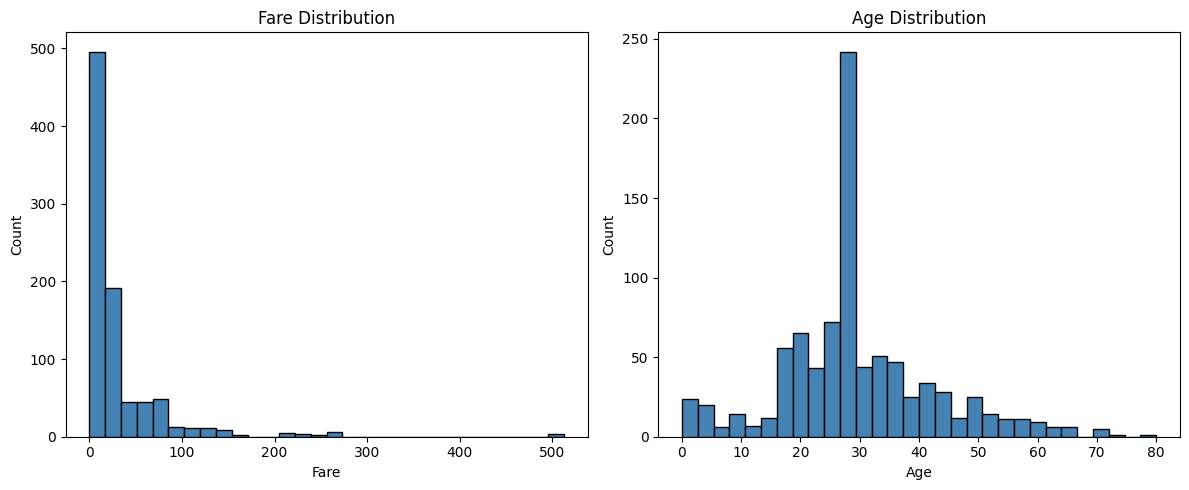

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['Fare'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Fare Distribution')
axes[0].set_xlabel('Fare')
axes[0].set_ylabel('Count')

axes[1].hist(df['Age'], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Visual Normality Check — Histogram + Normal Curve

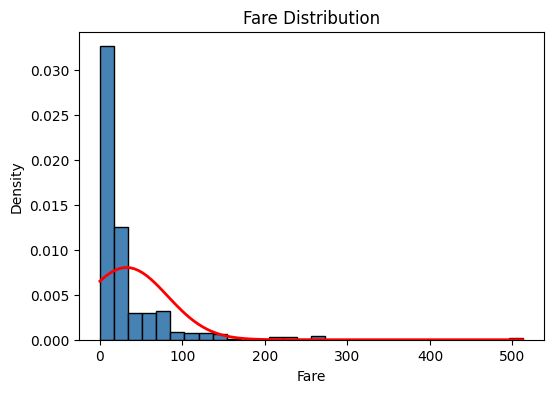

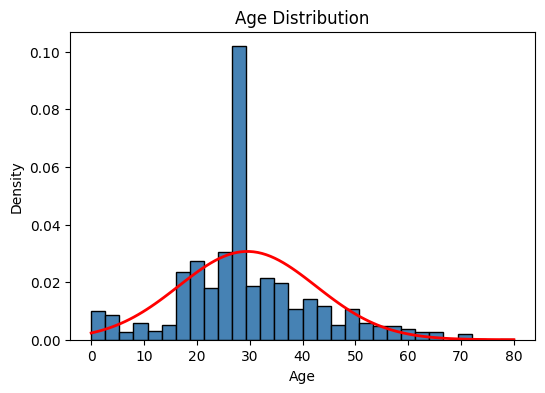

In [10]:
# Fare
plt.figure(figsize=(6, 4))
mu, std = df['Fare'].mean(), df['Fare'].std()
x = np.linspace(df['Fare'].min(), df['Fare'].max(), 100)
plt.hist(df['Fare'], bins=30, color='steelblue', edgecolor='black', density=True)
plt.plot(x, stats.norm.pdf(x, mu, std), color='red', linewidth=2)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Density')
plt.show()

# Age
plt.figure(figsize=(6, 4))
mu, std = df['Age'].mean(), df['Age'].std()
x = np.linspace(df['Age'].min(), df['Age'].max(), 100)
plt.hist(df['Age'], bins=30, color='steelblue', edgecolor='black', density=True)
plt.plot(x, stats.norm.pdf(x, mu, std), color='red', linewidth=2)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

Shapiro-Wilk Test — Statistical Proof

In [11]:
from scipy.stats import shapiro

print("=== NORMALITY TEST ===\n")

stat, p = shapiro(df['Fare'])
print(f"Fare: p-value = {p:.4f}")

stat, p = shapiro(df['Age'])
print(f"Age: p-value = {p:.4f}")

stat, p = shapiro(df['SibSp'])
print(f"SibSp: p-value = {p:.4f}")

stat, p = shapiro(df['Parch'])
print(f"Parch: p-value = {p:.4f}")

=== NORMALITY TEST ===

Fare: p-value = 0.0000
Age: p-value = 0.0000
SibSp: p-value = 0.0000
Parch: p-value = 0.0000


QQ Plot — Visual Straight-Line Check

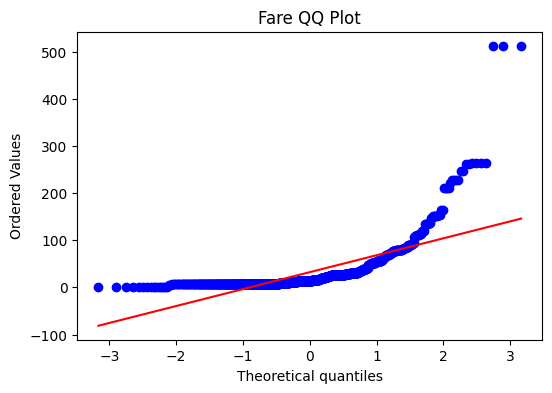

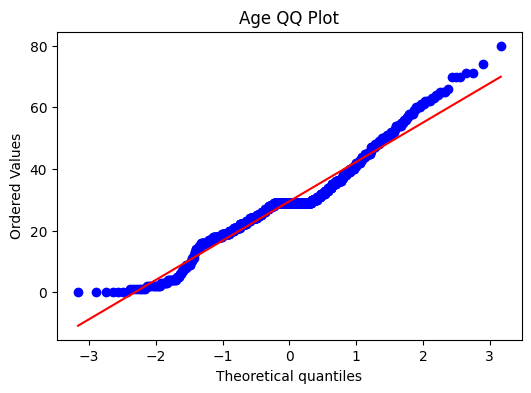

In [12]:
# Fare QQ Plot
plt.figure(figsize=(6, 4))
stats.probplot(df['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')
plt.show()

# Age QQ Plot
plt.figure(figsize=(6, 4))
stats.probplot(df['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')
plt.show()

Log Transformation — Fixing the Skew

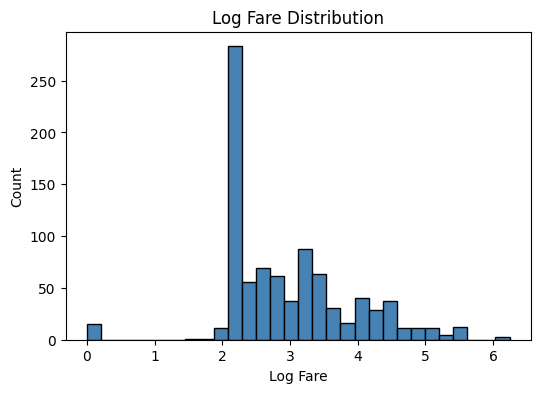

In [13]:
# Log Fare (add 1 to avoid log(0) errors since some fares are 0)
plt.figure(figsize=(6, 4))
plt.hist(np.log(df['Fare'] + 1), bins=30, color='steelblue', edgecolor='black')
plt.title('Log Fare Distribution')
plt.xlabel('Log Fare')
plt.ylabel('Count')
plt.show()

Test 1 — Chi-Square: Does Sex affect Survival?

H0: Sex and Survival are independent (no relationship)

H1: Sex and Survival are related

In [15]:
contingency = pd.crosstab(df['Sex'], df['Survived'])
print(contingency)

stat, p, dof, expected = chi2_contingency(contingency)
print(f"\nChi-Square Test (Sex vs Survived)")
print(f"p-value = {p:.4f}")
if p < 0.05:
    print("✅ Reject H0 - Sex significantly affects survival")
else:
    print("❌ Fail to reject H0 - No significant relationship")

Survived    0    1
Sex               
0         468  109
1          81  233

Chi-Square Test (Sex vs Survived)
p-value = 0.0000
✅ Reject H0 - Sex significantly affects survival


Test 3 — T-test: Does Fare differ between Survivors and Non-survivors?
H0: Average fare is the same for survivors and non-survivors

H1: Average fare is different between the two groups

In [16]:
fare_survived = df[df['Survived'] == 1]['Fare']
fare_died = df[df['Survived'] == 0]['Fare']

stat, p = ttest_ind(fare_survived, fare_died)
print(f"T-test (Fare: Survived vs Died)")
print(f"p-value = {p:.4f}")
if p < 0.05:
    print("✅ Reject H0 - Fare significantly differs between survivors and non-survivors")
else:
    print("❌ Fail to reject H0 - No significant difference")

T-test (Fare: Survived vs Died)
p-value = 0.0000
✅ Reject H0 - Fare significantly differs between survivors and non-survivors


Test 4 — T-test: Does Age differ between Survivors and Non-survivors?
H0: Average age is the same for survivors and non-survivors

H1: Average age is different between the two groups
python

In [17]:
age_survived = df[df['Survived'] == 1]['Age']
age_died = df[df['Survived'] == 0]['Age']

stat, p = ttest_ind(age_survived, age_died)
print(f"\nT-test (Age: Survived vs Died)")
print(f"p-value = {p:.4f}")
if p < 0.05:
    print("✅ Reject H0 - Age significantly differs between survivors and non-survivors")
else:
    print("❌ Fail to reject H0 - No significant difference")


T-test (Age: Survived vs Died)
p-value = 0.0430
✅ Reject H0 - Age significantly differs between survivors and non-survivors


Test 5 — ANOVA: Does Fare differ across the 3 Embarked ports?

H0: Average fare is the same across all 3 ports

H1: At least one port has a different average fare

In [18]:
fare_S = df[df['Embarked'] == 0]['Fare']
fare_C = df[df['Embarked'] == 1]['Fare']
fare_Q = df[df['Embarked'] == 2]['Fare']

stat, p = f_oneway(fare_S, fare_C, fare_Q)
print(f"\nANOVA (Fare across Embarked ports)")
print(f"p-value = {p:.4f}")
if p < 0.05:
    print("✅ Reject H0 - Fare significantly differs across embarkation ports")
else:
    print("❌ Fail to reject H0 - No significant difference")


ANOVA (Fare across Embarked ports)
p-value = 0.0000
✅ Reject H0 - Fare significantly differs across embarkation ports


Correlation vs Causation


Correlation with Survival

In [24]:
df.drop(['Unnamed: 0', 'PassengerId'], axis=1, inplace=True, errors='ignore')

In [25]:
print(df.corr()['Survived'].sort_values(ascending=False))

Survived    1.000000
Sex         0.543351
Fare        0.257307
Embarked    0.106811
Parch       0.081629
SibSp      -0.035322
Age        -0.067809
Pclass     -0.338481
Name: Survived, dtype: float64


Correlation heatmap

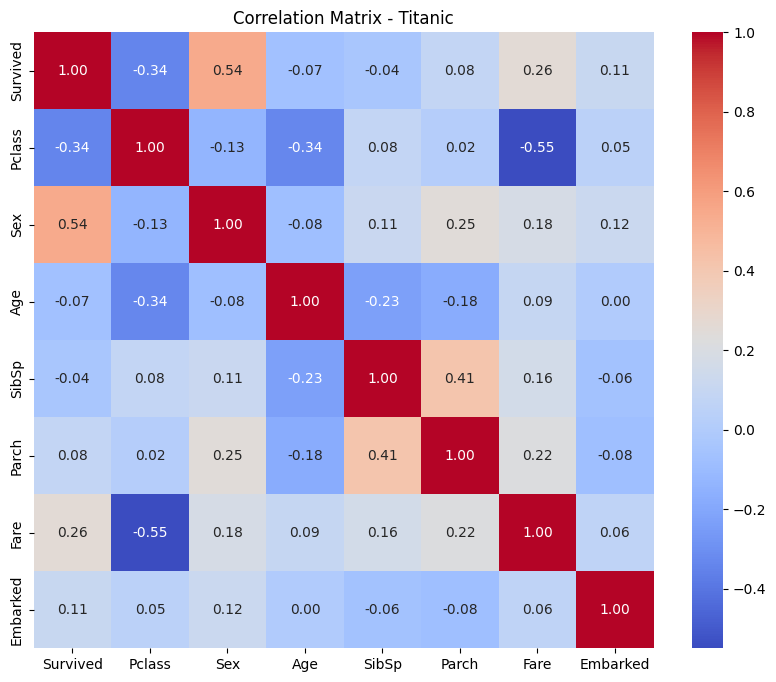

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix - Titanic')
plt.show()

Cofounding Variables

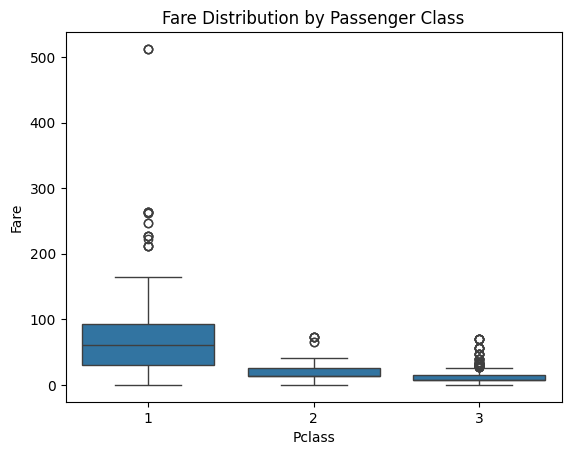

In [27]:
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title('Fare Distribution by Passenger Class')
plt.xlabel('Pclass')
plt.ylabel('Fare')
plt.show()

Multiple Logistic Regression — Isolating Each Feature's Effect

In [ ]:
X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

print("Coefficients (effect of each feature, holding others constant):")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")

Coefficients (effect of each feature, holding others constant):
Pclass: -1.1143
Sex: 2.5132
Age: -0.0326
Fare: 0.0008


: 